<p style="background: #E1DEDE; border:1px black  solid;  padding: 10px">Представьте, что вы работаете в международной гуманитарной организации, главная задача которой — борьба с бедностью и помощь людям из наименее развитых стран. Для выполнения своей миссии ваша организация периодически финансирует различные проекты, поддерживающие нуждающиеся регионы.<br>
Вы собрали 100 миллионов долларов и должны принять решение, как распределить эти деньги — в какие страны их направить в первую очередь. Как выбрать, кто сильнее всего нуждается в финансовой поддержке?<br>
Конечно, можно взять страны с самыми низкими доходами населения или с самой маленькой продолжительностью жизни. А может, лучше помочь странам, у которых самая высокая инфляция? По отдельным признакам выбирать достаточно сложно — нам хотелось бы выявить группы стран, в которых в целом ситуация вызывает опасения по совокупности значений всех признаков.

Для решения этой задачи мы как раз и используем наши навыки в снижении размерности и кластеризации данных: попробуем выделить кластеры стран, схожих по своим характеристикам, и среди них выявить кластер особо нуждающихся.

Данные содержат следующие признаки:

- country — название страны;
- child_mort — показатель смертности детей до 5 лет;
- exports — показатель экспорта на душу населения;
- health — показатель затрат на здравоохранение на душу населения;
- imports — показатель импорта на душу населения;
- Income — средний доход на душу населения;
- Inflation — годовой показатель инфляции;
- life_expec — средняя продолжительность жизни;
- total_fer — суммарный коэффициент рождаемости;
- gdpp — значение ВВП на душу населения.

In [106]:
import pandas as pd
import numpy as np

data = pd.read_csv('data\Country-data.csv')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


**Задание 7.1**

Каково максимальное значение показателя средней продолжительности жизни среди представленных стран? Ответ округлите до одного знака после точки-разделителя.

In [9]:
data['life_expec'].describe()['max']

82.8

**Задание 7.2**

Чтобы получить более качественные результаты, необходимо стандартизировать данные. Используйте для этого StandardScaler. Примените его ко всем значениям признаков и впишите в качестве ответа значение первого признака для первого объекта (таким образом можно будет проверить, что вы всё сделали корректно). Ответ округлите до двух знаков после точки-разделителя.

In [28]:
from sklearn import preprocessing

# удалим признак country
data_num = data.drop(columns='country', inplace=True)
features = data.columns
#Инициализируем стандартизатор StandardScaler
scaler = preprocessing.StandardScaler()
#Производим стандартизацию
data_scaled = scaler.fit_transform(data_num)
#Составляем DataFrame из результата
data_scaled_df = pd.DataFrame(data_scaled, columns=features)



print('значение первого признака для первого объекта:', data_scaled[0][0].round(2))

значение первого признака для первого объекта: 1.29


**Задание 7.3**

Как вы помните, нет смысла использовать сильно связанные друг с другом признаки, так как их можно преобразовать в один и таким образом уменьшить общее количество признаков. Давайте выясним, есть ли в данных такие признаки.

Постройте матрицу корреляций для всех признаков. Найдите максимальный коэффициент корреляции. Запишите его в качестве ответа, предварительно округлив до двух знаков после точки-разделителя.

максимальный коэффициент корреляции: 0.9


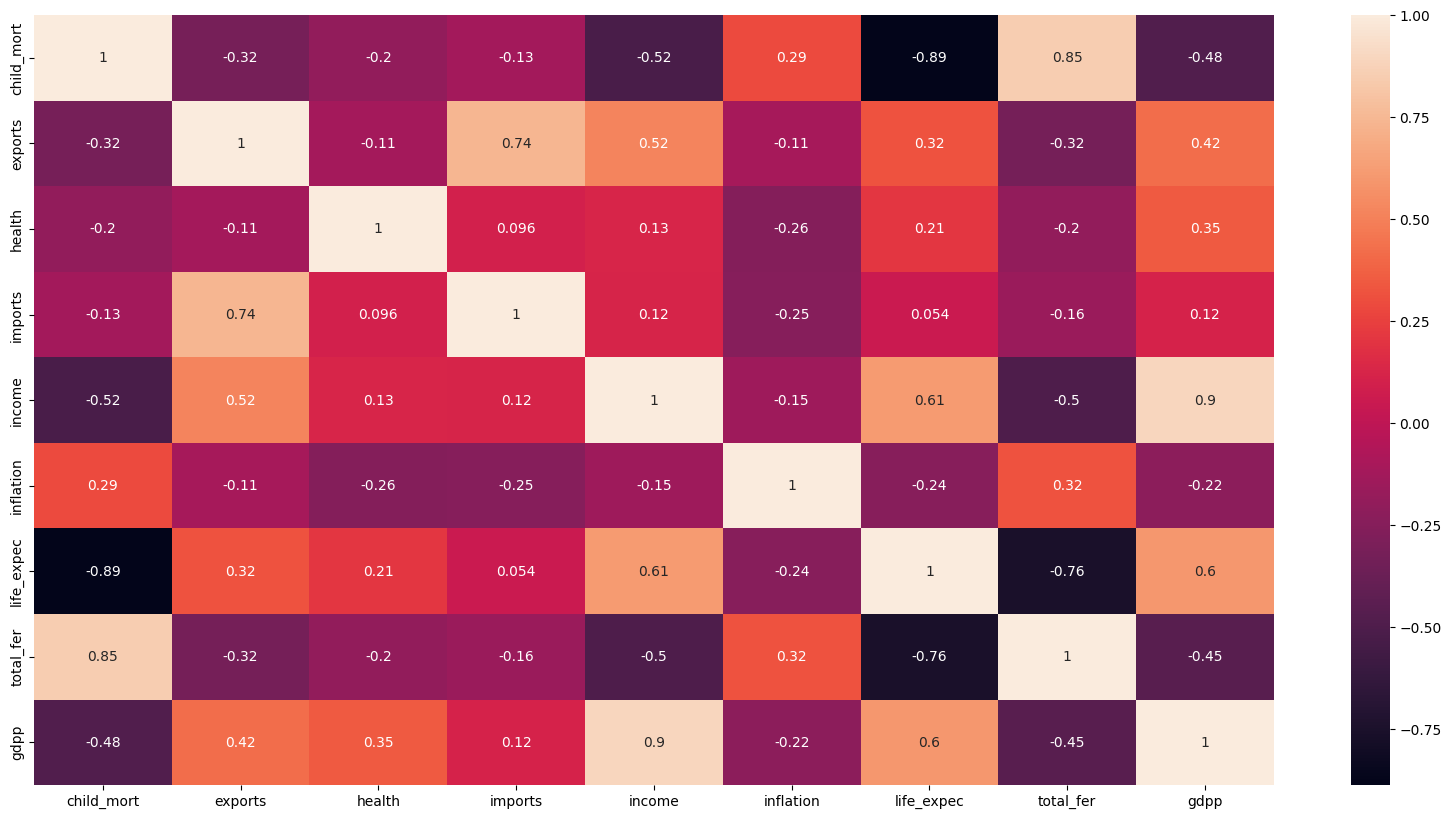

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (20,10))       
sns.heatmap(data_scaled_df.corr(),annot = True)

#C = data_scaled_df.corr()
print('максимальный коэффициент корреляции:', C.iloc[4][8].round(2))

**Задание 7.4**

Теперь понизим размерность данных — возьмём для этого метод главных компонент (PCA) как самый простой и популярный.

Найдите минимальное число компонент, которые суммарно могут объяснить как минимум 90 % разброса данных.

In [55]:
from sklearn.decomposition import PCA

#определяем минимальное кол-во компонент
pca = PCA(n_components=0.9)
#обучаем алгоритм на наших данных
principalComponents = pca.fit_transform(data_scaled)
print('минимальное количество главных компонент:', pca.n_components_)
#или
#len(pca.components_)

минимальное количество главных компонент: 5


**Задание 7.5**

Используйте главные компоненты, выделенные в предыдущем задании.

Какую долю дисперсии объясняет первая главная компонента? Ответ округлите до двух знаков после точки-разделителя.

In [61]:
print('доля дисперсии, которую объясняет первая главная компонента:',pca.explained_variance_ratio_[0].round(2))

доля дисперсии, которую объясняет первая главная компонента: 0.46


**Задание 7.6**

Как вы помните, при создании компонент с помощью PCA они должны получиться независимыми, то есть мы не должны теперь наблюдать высоких коэффициентов корреляции.

Постройте матрицу корреляций. Сколько значений в ней превышают 0.001, не считая единичных значений на главной диагонали?

<Axes: >

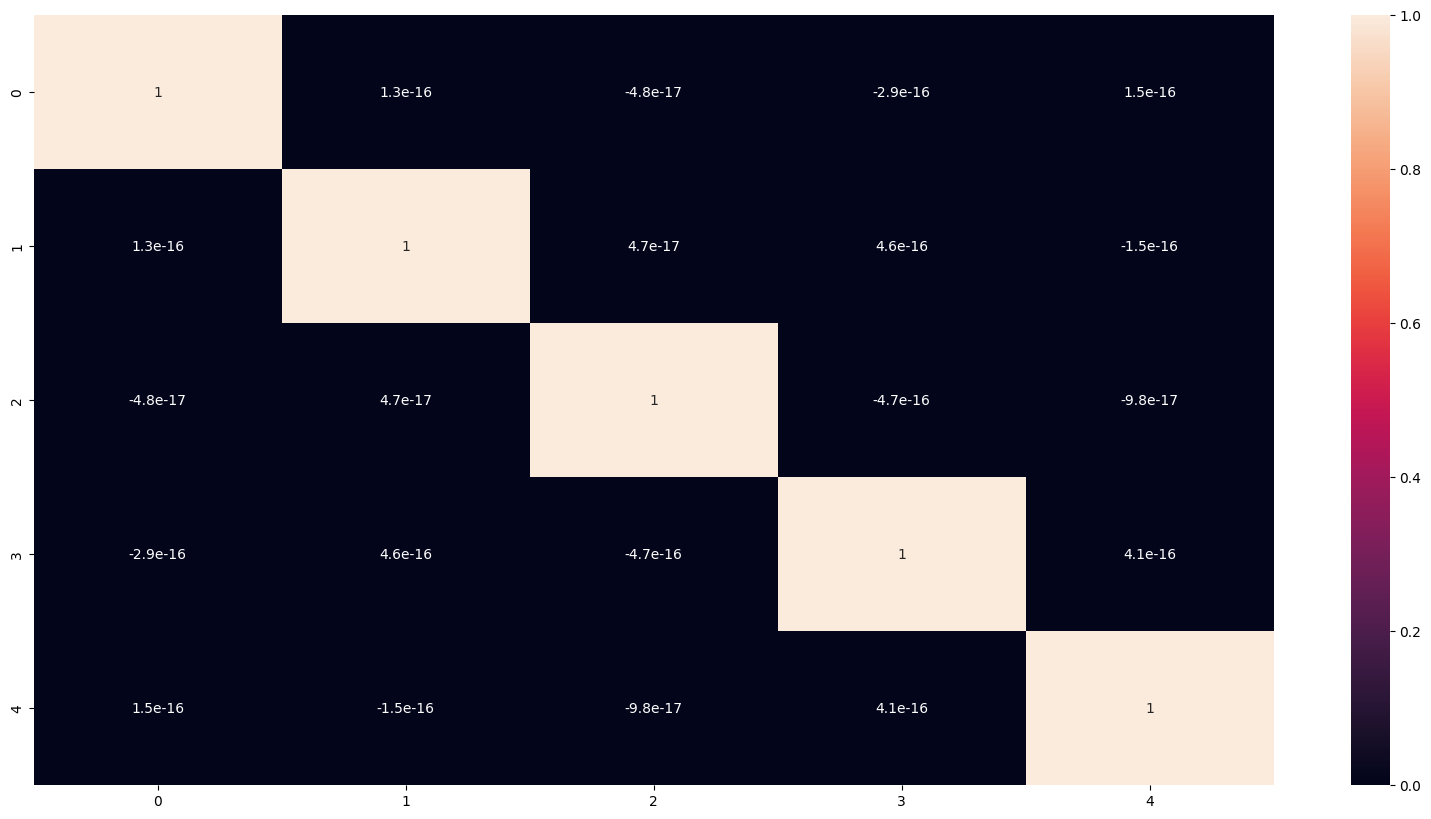

In [79]:
principalComponents_df = pd.DataFrame(principalComponents)
plt.figure(figsize = (20,10))       
sns.heatmap(principalComponents_df.corr(),annot = True)

<Axes: >

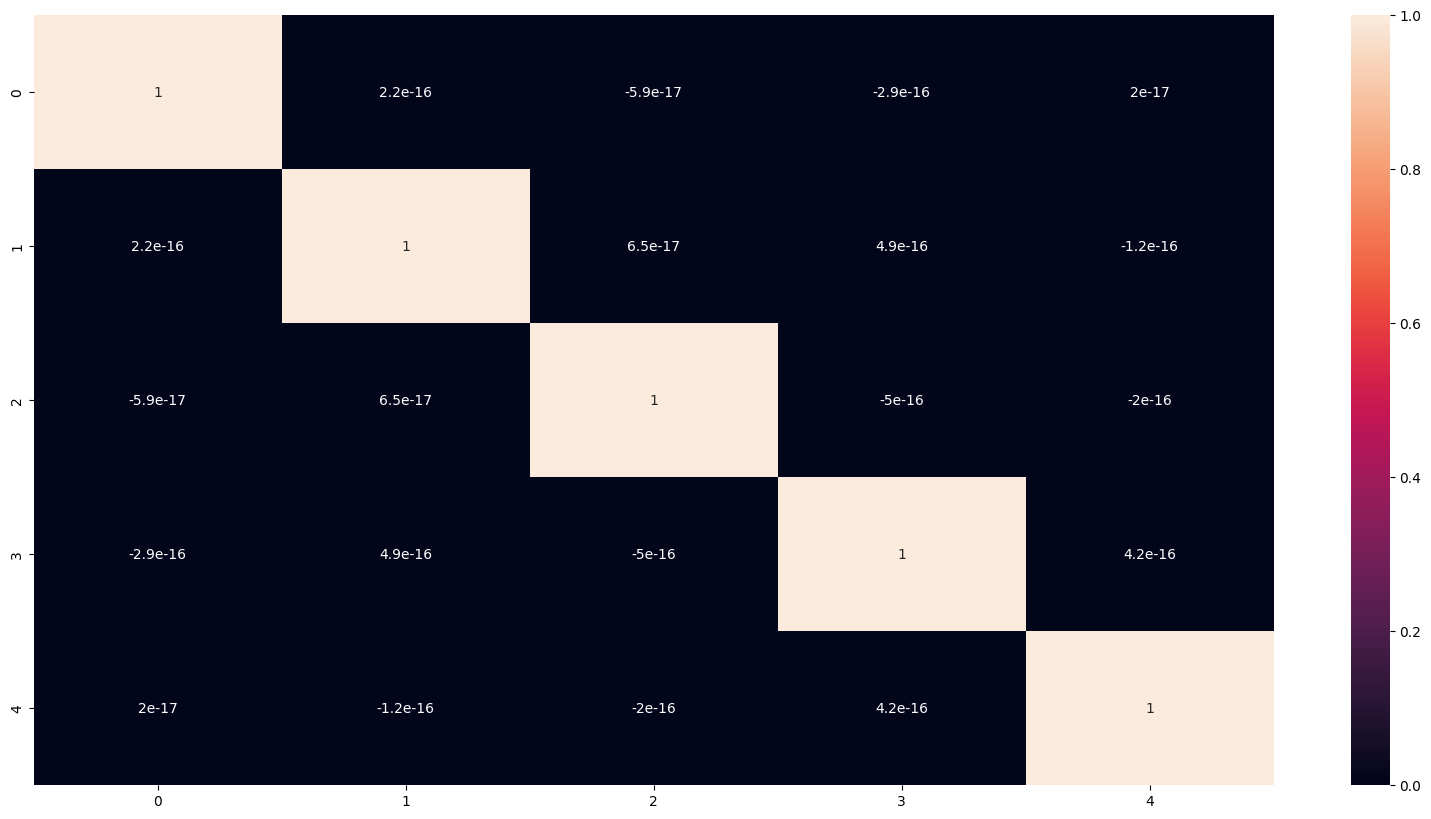

In [81]:
# или
X_pca = pca.fit_transform(data_scaled)
corrmat = np.corrcoef(X_pca.transpose())
plt.figure(figsize = (20,10))  
sns.heatmap(corrmat, annot=True)

*0 значений в матрице корреляций превышают 0.001*

**Задание 7.7**

Теперь, когда мы уменьшили размерность данных, можно переходить к кластеризации. Подберите оптимальное количество кластеров с помощью коэффициента силуэта, перебирая возможные значения от 2 до 10 включительно. Для кластеризации используйте алгоритм k-means++. В качестве значения параметра random_state возьмите число 1.

Судя по полученным результатам, сколько кластеров лучше всего взять?

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_in

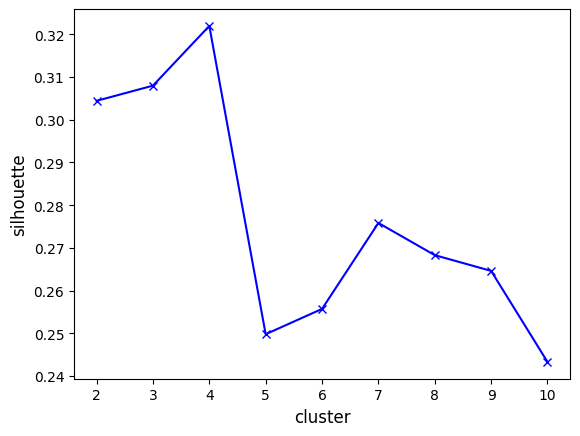

In [86]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def get_silhouette(cluster_num, X):
    k_means =  KMeans(n_clusters=cluster_num, random_state=1)
    k_means.fit(X)
    silhouette = silhouette_score(X, k_means.labels_, metric='euclidean')
    return silhouette

silhouettes = []
for i in range(2, 11):
    silhouettes.append(get_silhouette(i, X_pca))
    
plt.xlabel("cluster", fontsize=12)
plt.ylabel("silhouette", fontsize=12)
plt.plot([i for i in range(2, 11)], silhouettes, 'xb-')

*оптимальное значение кластеров: 4*

**Задание 7.8**

Теперь, когда оптимальное количество кластеров выбрано, реализуйте алгоритм k-means++ с этим параметром. В качестве значения random_state возьмите число 1.

В какой кластер попали страны, у которых самый высокий показатель детской смертности и самый низкий ВВП на душу населения?

c:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: xlabel='cluster', ylabel='child_mort'>

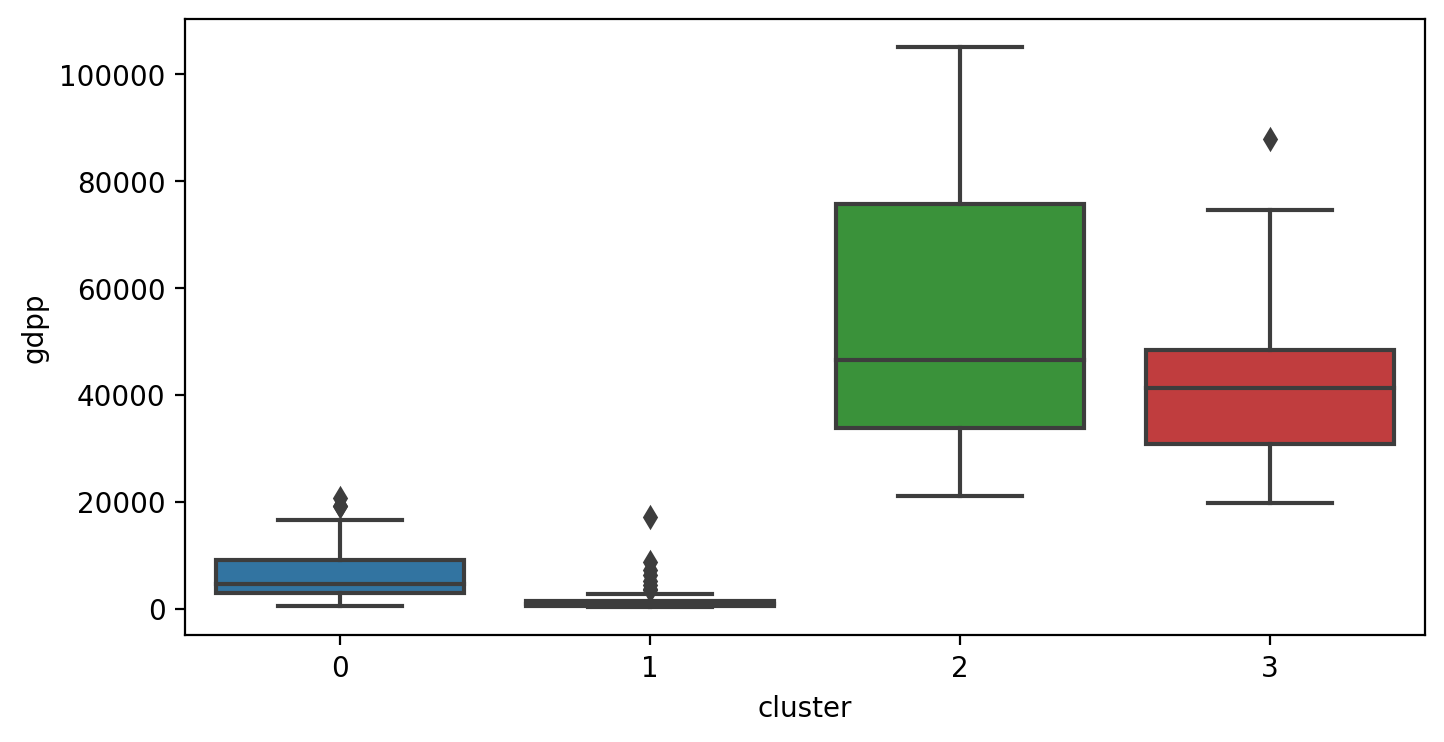

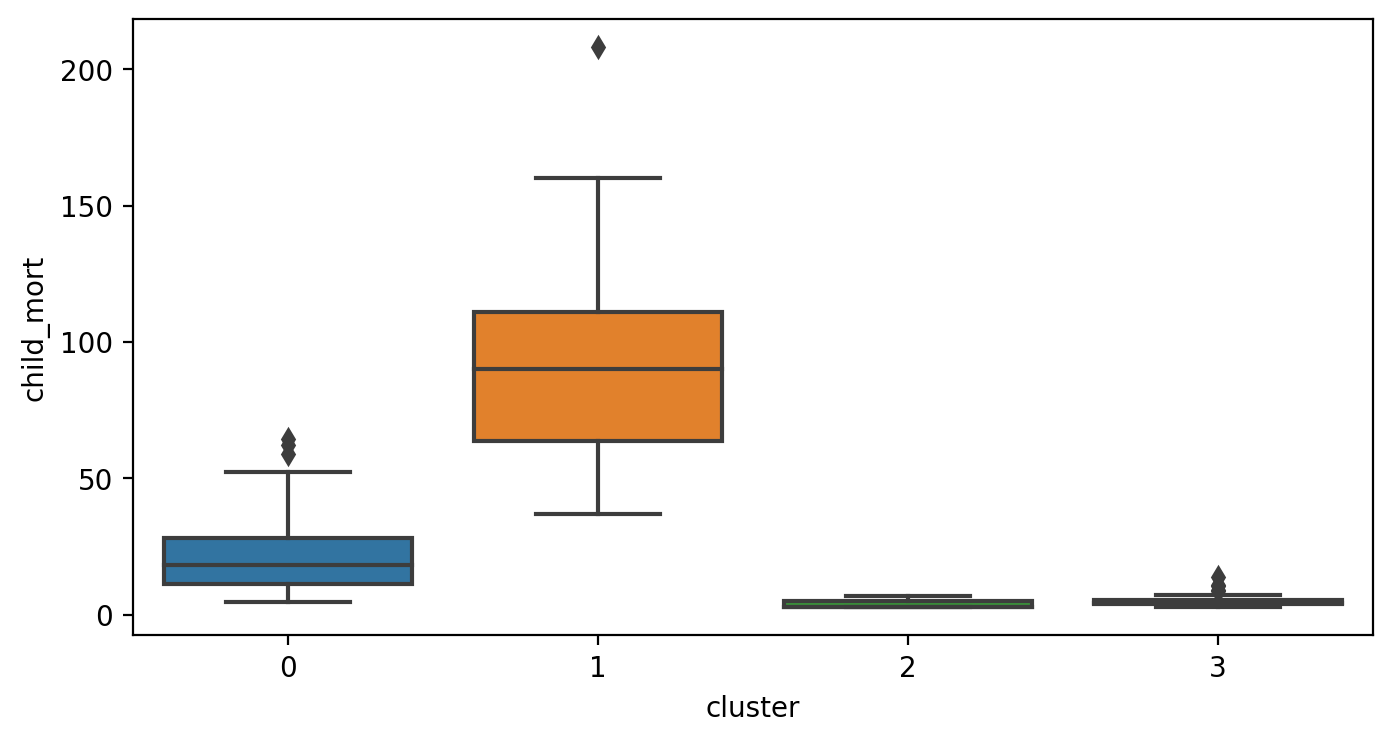

In [107]:
kmeans = KMeans(n_clusters=4, random_state=1)
kmeans.fit(X_pca)
data['cluster'] = kmeans.labels_
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='cluster', y='gdpp', data=data)
plt.figure(figsize=(8,4),dpi=200)
sns.boxplot(x='cluster', y='child_mort', data=data)

*в 1ой группе*

**Задание 7.9**

Итак, мы понимаем, что именно в выбранном нами кластере находятся страны, которые особенно остро нуждаются в финансовой помощи. Однако на все страны у нас не хватит ресурсов, поэтому давайте выберем из выделенного кластера три страны, в которых самая маленькая продолжительность жизни.

In [115]:
mask = data['cluster']==1
data[mask].sort_values(by='life_expec', ascending=True).iloc[0:3]

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
66,Haiti,208.0,15.3,6.91,64.7,1500,5.45,32.1,3.33,662,1
87,Lesotho,99.7,39.4,11.10,101.0,2380,4.15,46.5,3.30,1170,1
31,Central African Republic,149.0,11.8,3.98,26.5,888,2.01,47.5,5.21,446,1
